In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

import pyswarms as ps
from deap import base, creator, tools, algorithms
import random

In [10]:
df = pd.read_csv('cleandata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

data = df[['demand_kWh']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

train_size = int(len(data_scaled) * 0.8)
train = data_scaled[:train_size]
test = data_scaled[train_size:]

In [11]:
#SARIMA Model
sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,24))
sarima_fit = sarima.fit(method='powell', maxiter=200, disp=False, 
                        low_memory=True, conserve_memory=True)

sarima_pred = sarima_fit.forecast(steps=len(test))
residuals = test.flatten() - sarima_pred.flatten()

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: conserve_memory. After release 0.14, this will raise.
  warnings.warn(


In [12]:
#create sequences for TCN
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X_res, y_res = create_sequences(residuals, window)
X_res = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))

In [13]:
def build_tcn(filters, kernel, lr):
    model = Sequential()
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel), activation='relu', input_shape=(window,1)))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

def fitness_eval(filters, kernel, lr):
    model = build_tcn(filters, kernel, lr)
    model.fit(X_res, y_res, epochs=3, batch_size=32, verbose=0)
    pred = model.predict(X_res, verbose=0)
    return mean_squared_error(y_res, pred)

In [14]:
#PSO Hyperparameter Optimization
bounds = ([16,2,0.0001],[128,5,0.01])
optimizer = ps.single.GlobalBestPSO(n_particles=5, dimensions=3, options={'c1':0.5, 'c2':0.3, 'w':0.9}, bounds=bounds)

best_cost_pso, best_pos_pso = optimizer.optimize(
    lambda x: np.array([fitness_eval(p[0], p[1], p[2]) for p in x]), iters=5)

print("PSO Best Hyperparameters:", best_pos_pso)
pso_model = build_tcn(best_pos_pso[0], best_pos_pso[1], best_pos_pso[2])
pso_model.fit(X_res, y_res, epochs=10, verbose=0)

2026-03-26 09:23:31,155 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                 |0/5

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-26 09:23:31,310 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **

PSO Best Hyperparameters: [6.71641206e+01 4.81074316e+00 1.83906319e-03]


In [15]:
#GA Hyperparameter Optimization
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("filters", random.randint, 16, 128)
toolbox.register("kernel", random.randint, 2, 5)
toolbox.register("lr", random.uniform, 0.0001, 0.01)
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.filters, toolbox.kernel, toolbox.lr), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_individual(ind):
    return (fitness_eval(ind[0], ind[1], ind[2]),)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best_ind = tools.selBest(pop, k=1)[0]
print("GA Best Hyperparameters:", best_ind)

ga_model = build_tcn(best_ind[0], best_ind[1], best_ind[2])
ga_model.fit(X_res, y_res, epochs=10, verbose=0)

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential mode

GA Best Hyperparameters: [40.0, 4.0, 0.005730273212405962]


C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
#final forecasts
res_pso = pso_model.predict(X_res).flatten()
res_ga = ga_model.predict(X_res).flatten()

final_pso = sarima_pred[window:].flatten() + res_pso
final_ga = sarima_pred[window:].flatten() + res_ga
actual = test.flatten()[window:]

324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step


In [17]:
#eval metrics
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)))

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} RESULTS")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape_val:.2f}%")
    print(f"R2: {r2:.4f}")
    return mae, rmse, smape_val, r2

metrics_pso = evaluate("SARIMA-PSO-TCN", actual, final_pso)
metrics_ga = evaluate("SARIMA-GA-TCN", actual, final_ga)


SARIMA-PSO-TCN RESULTS
MAE: 0.0405
RMSE: 0.0567
SMAPE: 30.28%
R2: 0.8805

SARIMA-GA-TCN RESULTS
MAE: 0.0445
RMSE: 0.0597
SMAPE: 33.03%
R2: 0.8678


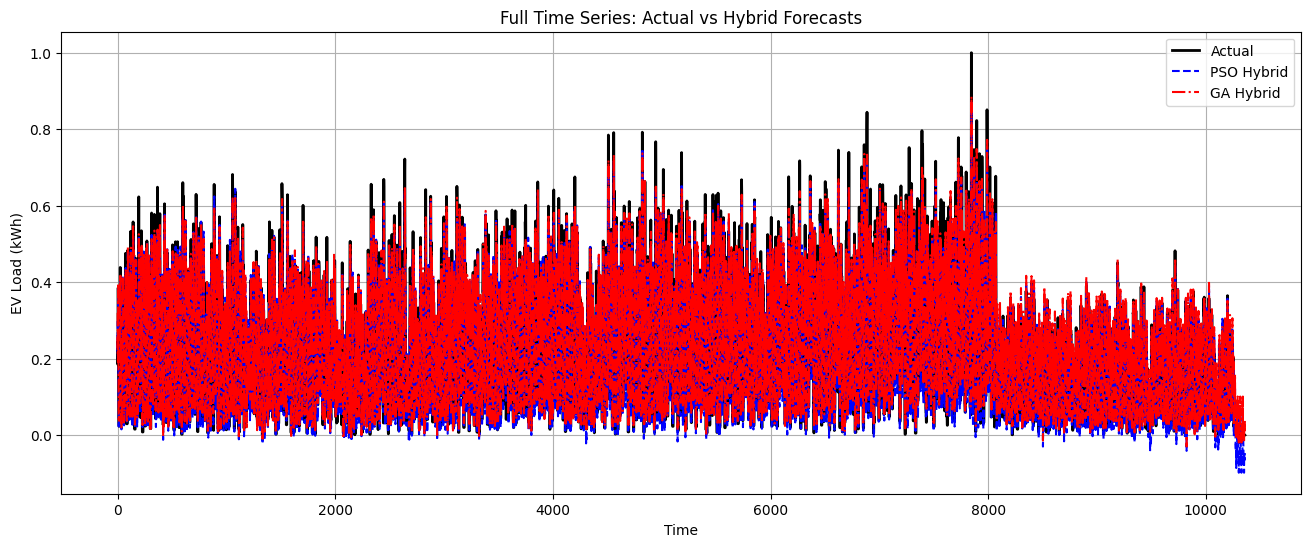

In [18]:
plt.figure(figsize=(16,6))
plt.plot(actual, label='Actual', color='black', linewidth=2)
plt.plot(final_pso, label='PSO Hybrid', color='blue', linestyle='--')
plt.plot(final_ga, label='GA Hybrid', color='red', linestyle='-.')
plt.title("Full Time Series: Actual vs Hybrid Forecasts")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

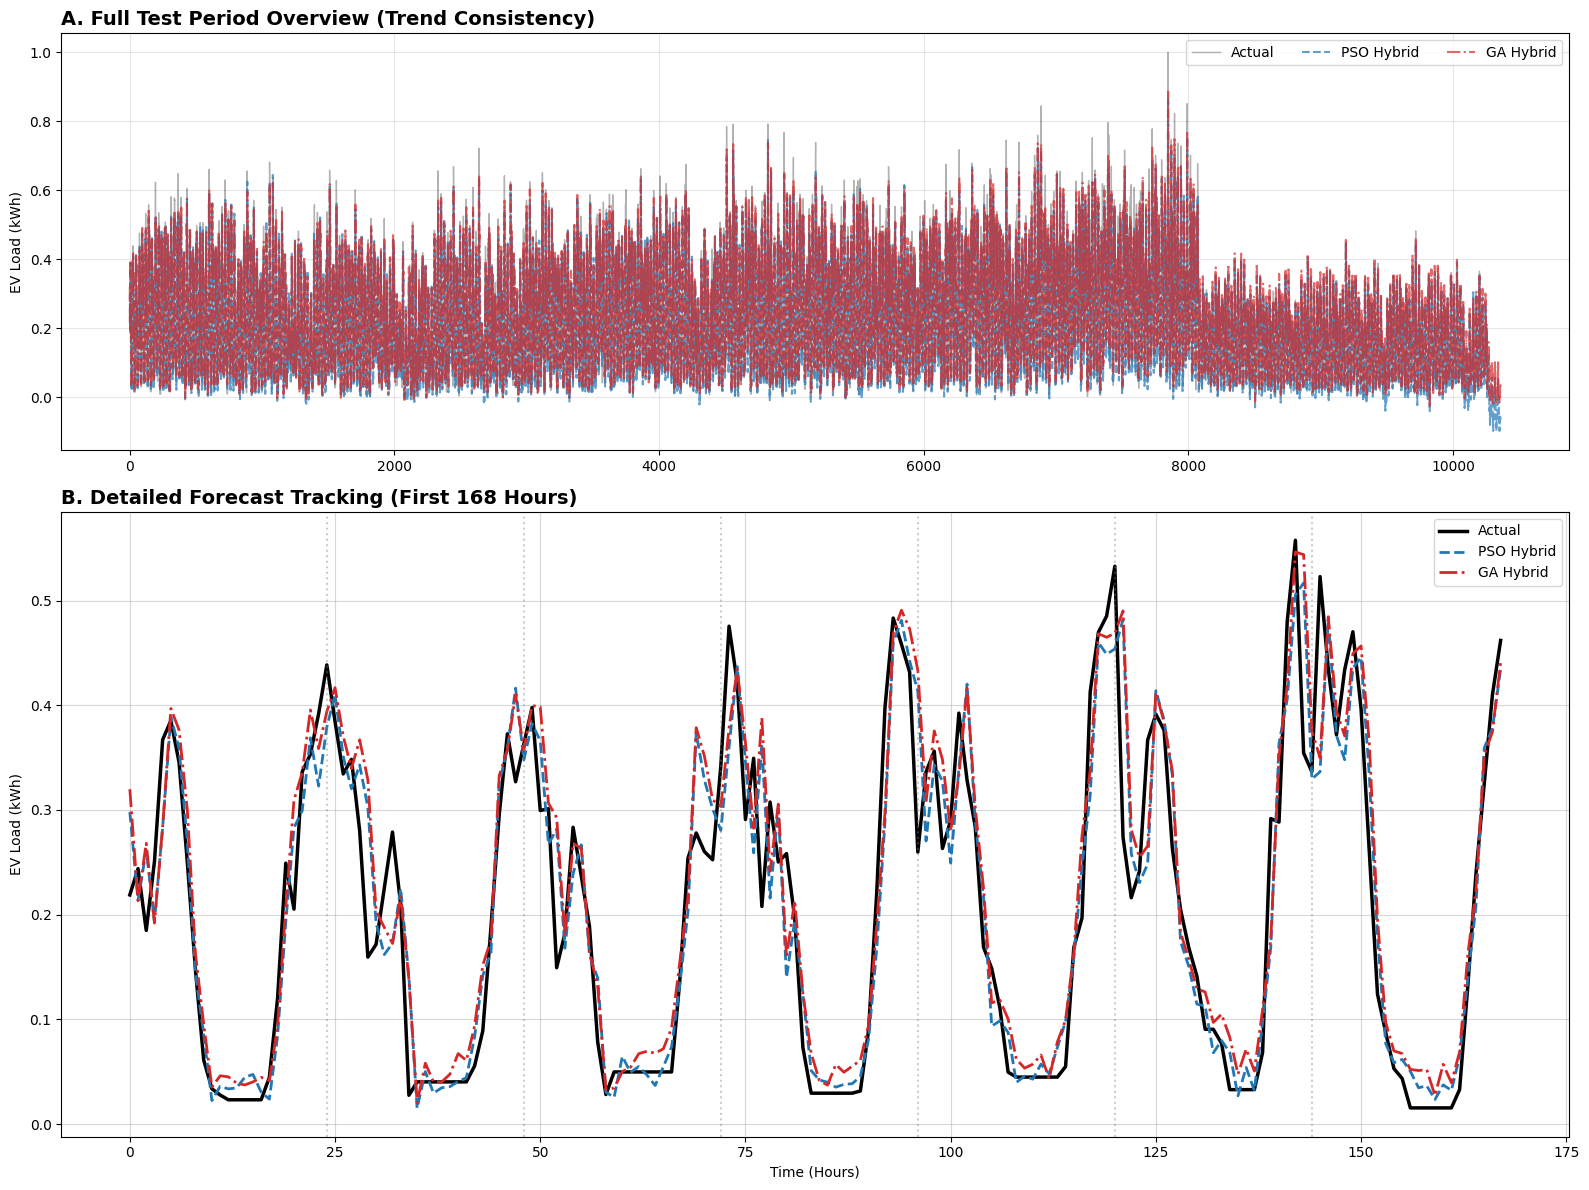

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})

ax1.plot(actual, label='Actual', color='black', alpha=0.3, linewidth=1)
ax1.plot(final_pso, label='PSO Hybrid', color='#1f77b4', alpha=0.7, linestyle='--')
ax1.plot(final_ga, label='GA Hybrid', color='#d62728', alpha=0.7, linestyle='-.')
ax1.set_title("A. Full Test Period Overview (Trend Consistency)", loc='left', fontsize=14, fontweight='bold')
ax1.set_ylabel("EV Load (kWh)")
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True, alpha=0.3)

zoom_range = 168  #One week of hourly data
ax2.plot(actual[:zoom_range], label='Actual', color='black', linewidth=2.5)
ax2.plot(final_pso[:zoom_range], label='PSO Hybrid', color='#1f77b4', linewidth=2, linestyle='--')
ax2.plot(final_ga[:zoom_range], label='GA Hybrid', color='#d62728', linewidth=2, linestyle='-.')

ax2.set_title(f"B. Detailed Forecast Tracking (First {zoom_range} Hours)", loc='left', fontsize=14, fontweight='bold')
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("EV Load (kWh)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

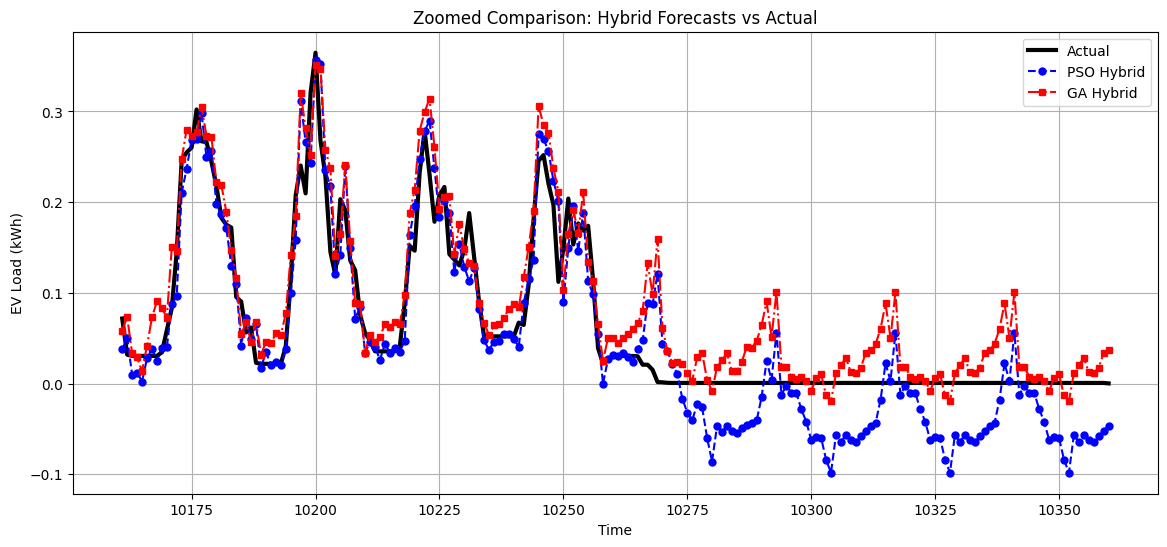

In [20]:
#zoomed forecast comparison
zoom_points = 200
x_zoom = range(len(actual)-zoom_points, len(actual))

plt.figure(figsize=(14,6))
plt.plot(x_zoom, actual[-zoom_points:], label='Actual', color='black', linewidth=3)
plt.plot(x_zoom, final_pso[-zoom_points:], label='PSO Hybrid', color='blue', linestyle='--', marker='o', markersize=5)
plt.plot(x_zoom, final_ga[-zoom_points:], label='GA Hybrid', color='red', linestyle='-.', marker='s', markersize=5)
plt.title("Zoomed Comparison: Hybrid Forecasts vs Actual")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

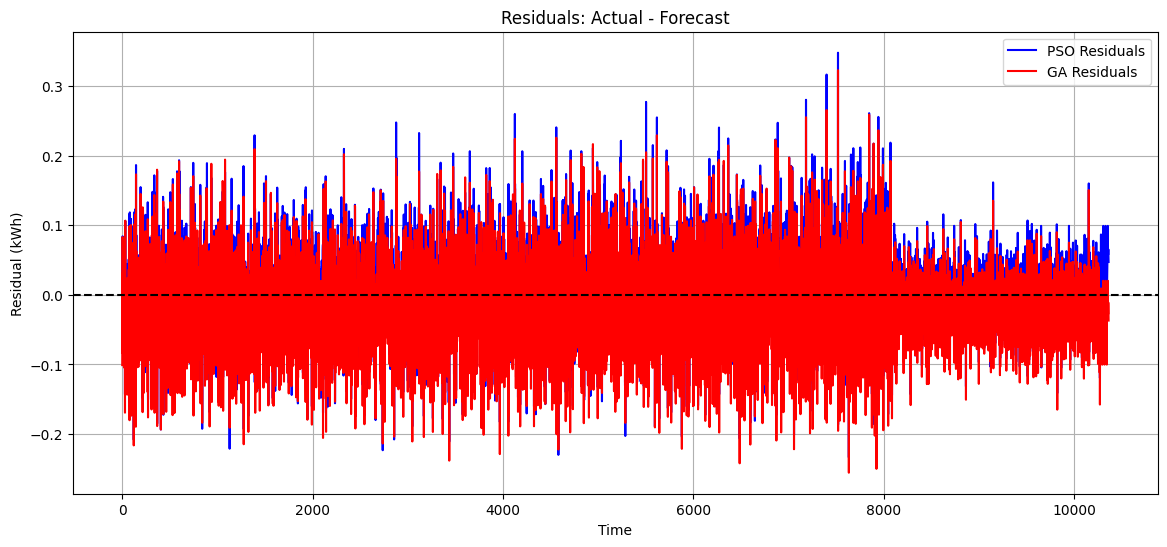

In [21]:
#residuals
residual_pso = actual - final_pso
residual_ga = actual - final_ga

plt.figure(figsize=(14,6))
plt.plot(residual_pso, label='PSO Residuals', color='blue')
plt.plot(residual_ga, label='GA Residuals', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals: Actual - Forecast")
plt.xlabel("Time")
plt.ylabel("Residual (kWh)")
plt.legend()
plt.grid(True)
plt.show()

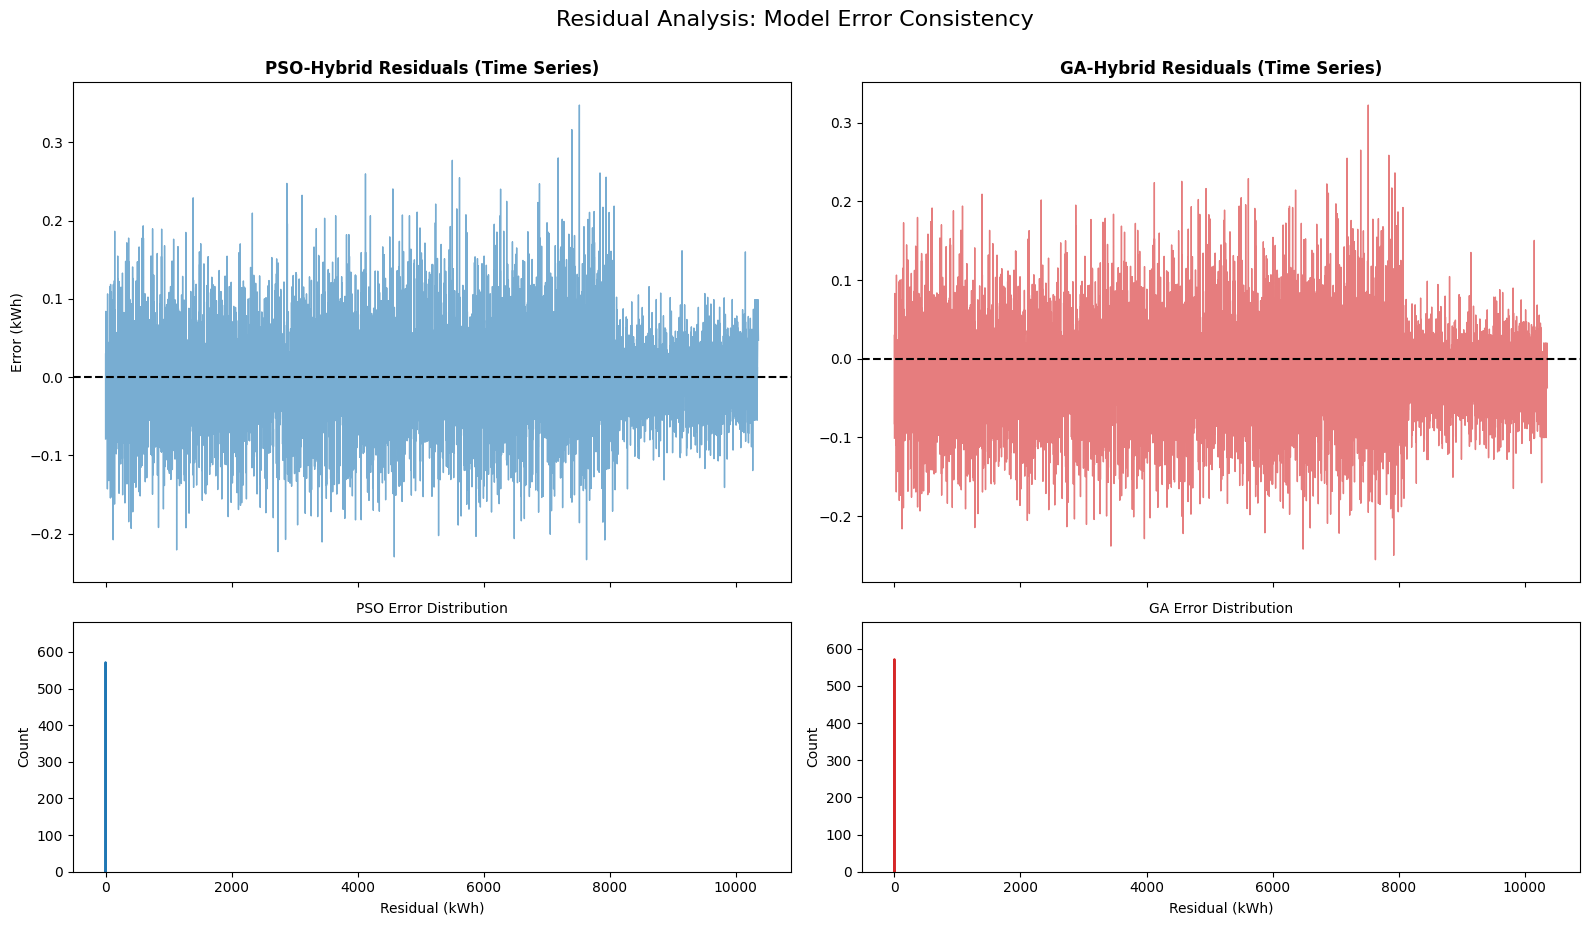

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [2, 1]})

# --- PSO RESIDUALS (Left Column) ---
# Line Plot
axes[0, 0].plot(residual_pso, color='#1f77b4', alpha=0.6, linewidth=1)
axes[0, 0].set_title('PSO-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 0].axhline(0, color='black', lw=1.5, ls='--')
axes[0, 0].set_ylabel('Error (kWh)')

# Histogram / KDE
sns.histplot(residual_pso, kde=True, ax=axes[1, 0], color='#1f77b4')
axes[1, 0].set_title('PSO Error Distribution', fontsize=10)
axes[1, 0].set_xlabel('Residual (kWh)')

# --- GA RESIDUALS (Right Column) ---
# Line Plot
axes[0, 1].plot(residual_ga, color='#d62728', alpha=0.6, linewidth=1)
axes[0, 1].set_title('GA-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 1].axhline(0, color='black', lw=1.5, ls='--')

# Histogram / KDE
sns.histplot(residual_ga, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('GA Error Distribution', fontsize=10)
axes[1, 1].set_xlabel('Residual (kWh)')

# Final formatting
plt.suptitle("Residual Analysis: Model Error Consistency", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

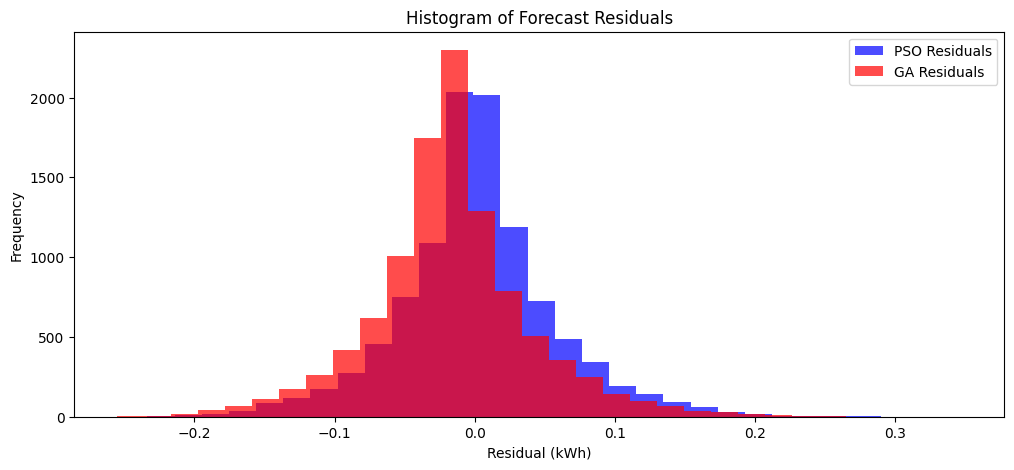

In [23]:
#histogram of residuals
plt.figure(figsize=(12,5))
plt.hist(residual_pso, bins=30, alpha=0.7, label='PSO Residuals', color='blue')
plt.hist(residual_ga, bins=30, alpha=0.7, label='GA Residuals', color='red')
plt.title("Histogram of Forecast Residuals")
plt.xlabel("Residual (kWh)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

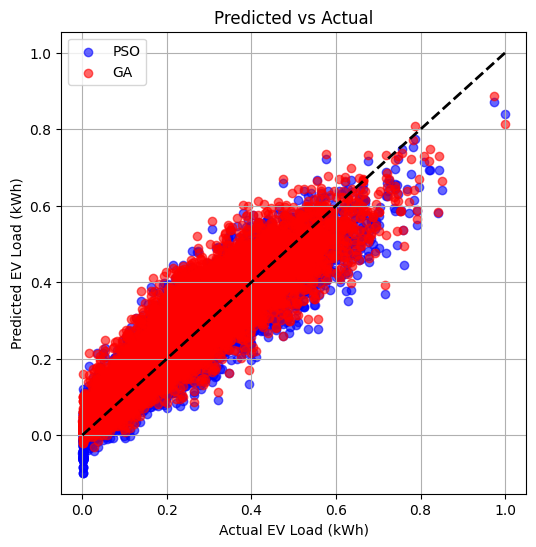

In [24]:
#scatter Plot: predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(actual, final_pso, label='PSO', color='blue', alpha=0.6)
plt.scatter(actual, final_ga, label='GA', color='red', alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--', lw=2)
plt.xlabel("Actual EV Load (kWh)")
plt.ylabel("Predicted EV Load (kWh)")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

            Model       MAE      RMSE      SMAPE        R2
0  SARIMA-PSO-TCN  0.040480  0.056748  30.281918  0.880464
1   SARIMA-GA-TCN  0.044536  0.059686  33.031259  0.867763


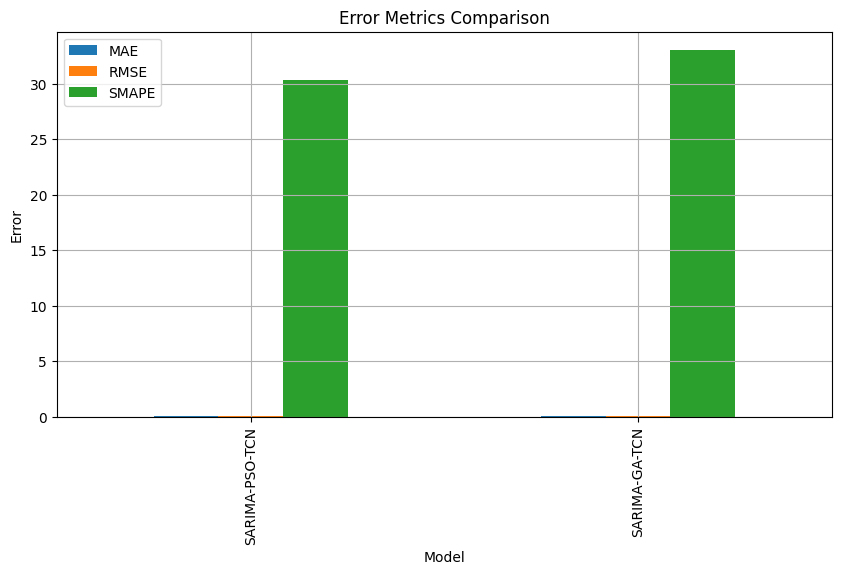

In [25]:
#metrics cmparison
metrics_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso[0], metrics_ga[0]],
    'RMSE': [metrics_pso[1], metrics_ga[1]],
    'SMAPE': [metrics_pso[2], metrics_ga[2]],
    'R2': [metrics_pso[3], metrics_ga[3]]
})
print(metrics_df)

metrics_df.set_index('Model')[['MAE','RMSE','SMAPE']].plot(kind='bar', figsize=(10,5))
plt.title("Error Metrics Comparison")
plt.ylabel("Error")
plt.grid(True)
plt.show()


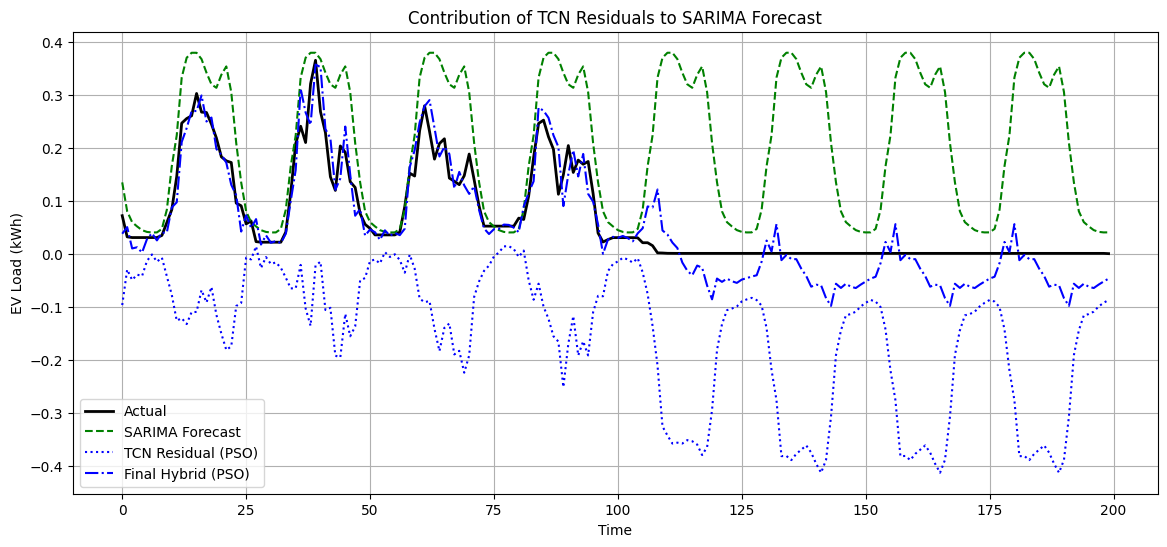

In [26]:
#TCN contribution to SARIMA forecast
plt.figure(figsize=(14,6))
plt.plot(actual[-zoom_points:], label='Actual', color='black', linewidth=2)
plt.plot(sarima_pred[window:][-zoom_points:], label='SARIMA Forecast', color='green', linestyle='--')
plt.plot(res_pso[-zoom_points:], label='TCN Residual (PSO)', color='blue', linestyle=':')
plt.plot(final_pso[-zoom_points:], label='Final Hybrid (PSO)', color='blue', linestyle='-.')
plt.title("Contribution of TCN Residuals to SARIMA Forecast")
plt.xlabel("Time")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import pandas as pd

# Extract PSO results
pso_params = {
    "filters": int(best_pos_pso[0]),
    "kernel_size": int(best_pos_pso[1]),
    "learning_rate": float(best_pos_pso[2])
}

# Extract GA results
ga_params = {
    "filters": int(best_ind[0]),
    "kernel_size": int(best_ind[1]),
    "learning_rate": float(best_ind[2])
}

# Combine into DataFrame (same style as metrics table)
params_df = pd.DataFrame([
    {"Model": "SARIMA-PSO-TCN", **pso_params},
    {"Model": "SARIMA-GA-TCN", **ga_params}
]).set_index("Model")

params_df

NameError: name 'best_pos_pso' is not defined